<div align="center">

# Features Evaluation
</div>

In [1]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

### functions

In [3]:
def mrmr_rank(X, y, k, floor=1e-3):
    """Feature indices ordered by greedy FCQ-mRMR (len <= k). Relevance = ANOVA
    F-statistic (f_classif); redundancy = mean |Pearson corr| to already-selected
    features; score = relevance / redundancy (quotient / FCQ form). ALIGNED to the
    reference `mrmr` package (Mazzanti, the FCQ default): candidate pool restricted
    to relevance>0, each pairwise redundancy floored at `floor` (=0.001), and a
    feature whose mean redundancy to the selected set is 1.0 is rejected (score 0).
    Greedy-forward, so order[:m] is the m-feature subset for any m<=k -> compute
    once at max(k) and slice. Matches the package bit-for-bit on well-conditioned
    data; a 1-2 feature residual can appear only in float-tie / exact-duplicate
    edge cases (immaterial)."""
    X = np.asarray(X, float); y = np.asarray(y)
    n, p = X.shape
    with np.errstate(all="ignore"):
        F, _ = f_classif(X, y)
    F = np.nan_to_num(np.asarray(F, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    F = np.maximum(F, 0.0)
    pool = F > 0.0                                      # package: keep only relevance>0
    k = int(min(k, int(pool.sum())))
    if k <= 0:
        return np.array([], dtype=int)
    # z-score (guard zero-variance) so col dot-products == Pearson correlations
    sd = X.std(0); sd = np.where(sd < 1e-12, 1.0, sd)
    Z = (X - X.mean(0)) / sd
    remaining = pool.copy()
    first = int(np.argmax(np.where(pool, F, -np.inf)))  # step 1: most relevant
    selected = [first]; remaining[first] = False
    accum = np.zeros(p)                                 # sum of FLOORED |corr| to picks
    for _ in range(1, k):
        corr = np.abs((Z.T @ Z[:, selected[-1]]) / n)   # |corr| vs last pick
        corr = np.clip(np.nan_to_num(corr, nan=floor), floor, None)   # per-pair floor
        accum += corr
        den = accum / len(selected)                     # mean |corr| to selected
        den = np.where(np.isclose(den, 1.0), np.inf, den)   # reject perfect-redundant
        score = np.where(remaining, F / den, -np.inf)
        nxt = int(np.argmax(score))
        if not np.isfinite(score[nxt]):
            break
        selected.append(nxt); remaining[nxt] = False
    return np.array(selected, dtype=int)


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_grid(X_train, y_train, X_test, y_test, selected_idx,
                  C_grid, gamma_grid):

    X_train_sel = X_train[:, selected_idx]
    X_test_sel = X_test[:, selected_idx]

    scaler = StandardScaler()
    X_train_sel = scaler.fit_transform(X_train_sel)
    X_test_sel = scaler.transform(X_test_sel)

    shape = (len(C_grid), len(gamma_grid))

    auc_matrix = np.zeros(shape)
    ap_matrix = np.zeros(shape)
    f1_matrix = np.zeros(shape)
    precision_matrix = np.zeros(shape)
    sensitivity_matrix = np.zeros(shape)   # Recall
    specificity_matrix = np.zeros(shape)

    for i, C in enumerate(C_grid):
        for j, gamma in enumerate(gamma_grid):

            clf = SVC(
                kernel="rbf",
                C=C,
                gamma=gamma,
                class_weight="balanced",
                probability=True,
                random_state=42
            )

            clf.fit(X_train_sel, y_train)

            y_prob = clf.predict_proba(X_test_sel)[:, 1]
            y_pred = clf.predict(X_test_sel)

            auc_matrix[i, j] = roc_auc_score(y_test, y_prob)
            ap_matrix[i, j] = average_precision_score(y_test, y_prob)

            f1_matrix[i, j] = f1_score(y_test, y_pred, zero_division=0)
            precision_matrix[i, j] = precision_score(y_test, y_pred, zero_division=0)
            sensitivity_matrix[i, j] = recall_score(y_test, y_pred, zero_division=0)

            tn, fp, fn, tp = confusion_matrix(
                y_test,
                y_pred,
                labels=[0, 1]
            ).ravel()

            specificity_matrix[i, j] = tn / (tn + fp) if (tn + fp) > 0 else 0

    return (
        auc_matrix,
        ap_matrix,
        f1_matrix,
        precision_matrix,
        sensitivity_matrix,
        specificity_matrix
    )

### build X_train , y_train

In [27]:
import glob
file_list = sorted(glob.glob("../Features/Seizure/chb13_*.mat"))

for test_file in file_list:
    # Load test record
    with h5py.File(test_file, 'r') as f:
        X_test = f['all_feats'][:]
        y_test = f['all_labels'][:].squeeze()
    
    # Build training set from all other records
    X_train_list, y_train_list = [], []
    for train_file in file_list:
        if train_file == test_file:
            continue
        with h5py.File(train_file, 'r') as f:
            X_train_list.append(f['all_feats'][:])
            y_train_list.append(f['all_labels'][:].squeeze())
    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_train_list)


### Apply scaling

In [28]:

# Always scale after selection, fitting scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Select features

In [29]:
# ---- Inside the training fold ----
X_train_df = pd.DataFrame(X_train_scaled)

selected_idx_2 = mrmr_rank(
    X=X_train_df,
    y=pd.Series(y_train),
    k=50
)


In [34]:
C_GRID = [ 0.01,0.1,1,10,100]
GAMMA_GRID = [0.0001,0.1,0.01,0.001]

auc_mi,ap_mi,f1_mi,precision_mi,sensitivity_mi,specificity_mi  = evaluate_grid(
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    selected_idx_2,
    C_GRID,
    GAMMA_GRID
)

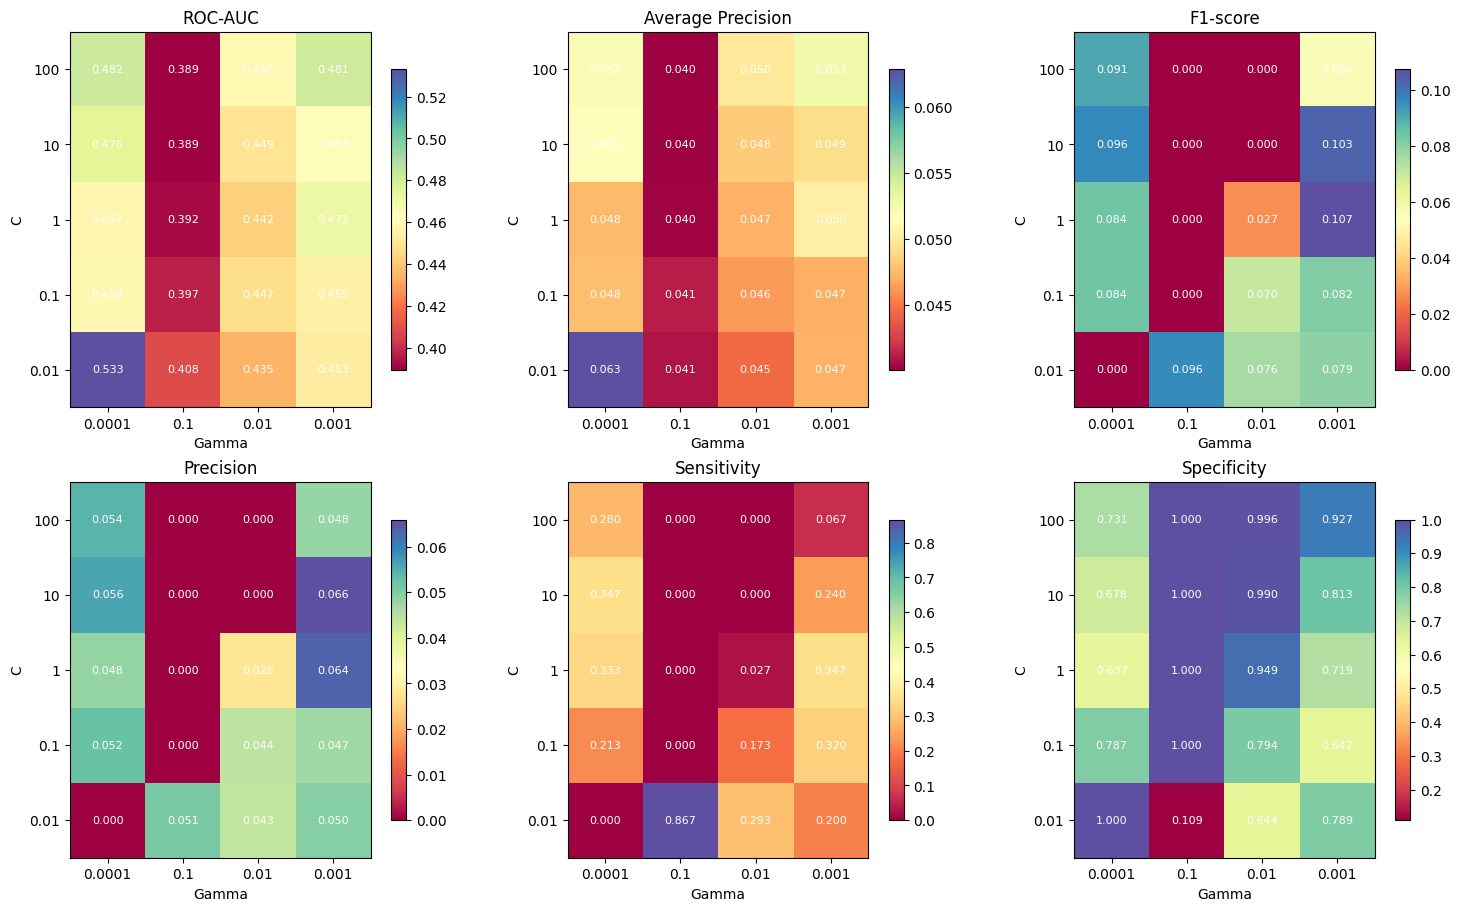

In [35]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ("ROC-AUC", auc_mi),
    ("Average Precision", ap_mi),
    ("F1-score", f1_mi),
    ("Precision", precision_mi),
    ("Sensitivity", sensitivity_mi),
    ("Specificity", specificity_mi),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

for ax, (title, data) in zip(axes.flat, metrics):

    im = ax.imshow(
        data,
        origin="lower",
        cmap="Spectral",
        aspect="equal",
        interpolation="nearest"
    )

    ax.set_title(title)
    ax.set_xlabel("Gamma")
    ax.set_ylabel("C")

    ax.set_xticks(np.arange(len(GAMMA_GRID)))
    ax.set_xticklabels(GAMMA_GRID)

    ax.set_yticks(np.arange(len(C_GRID)))
    ax.set_yticklabels(C_GRID)

    # Write values inside each cell
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(
                j, i,
                f"{data[i, j]:.3f}",
                ha="center",
                va="center",
                color="white",
                fontsize=8
            )

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.show()

### plotting

# Run for all

In [ ]:
# import glob
# import h5py
# import numpy as np
# import pandas as pd

# from sklearn.preprocessing import StandardScaler

# patients = [f"chb{i:02d}" for i in range(1, 5)]

# results = {}

# for patient in patients:

#     file_list = sorted(glob.glob(f"../Features/Seizure/{patient}_*.mat"))

#     if len(file_list) < 2:
#         print(f"Skipping {patient} (not enough records)")
#         continue

#     print(f"\n===== {patient} =====")

#     for test_file in file_list:

#         # --------------------------
#         # Load test record
#         # --------------------------
#         with h5py.File(test_file, "r") as f:
#             X_test = f["all_feats"][:]
#             y_test = f["all_labels"][:].squeeze()

#         # --------------------------
#         # Build training set
#         # --------------------------
#         X_train_list = []
#         y_train_list = []

#         for train_file in file_list:
#             if train_file == test_file:
#                 continue

#             with h5py.File(train_file, "r") as f:
#                 X_train_list.append(f["all_feats"][:])
#                 y_train_list.append(f["all_labels"][:].squeeze())

#         X_train = np.vstack(X_train_list)
#         y_train = np.concatenate(y_train_list)

#         # --------------------------
#         # Scale
#         # --------------------------
#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)

#         # --------------------------
#         # mRMR
#         # --------------------------
#         X_train_df = pd.DataFrame(X_train_scaled)

#         selected_idx_2 = mrmr_rank(
#             X=X_train_df,
#             y=pd.Series(y_train),
#             k=50
#         )

#         # --------------------------
#         # Evaluate
#         # --------------------------
#         C_GRID = [0.01,0.1, 1, 10, 100]
#         GAMMA_GRID = [0.0001, 0.001, 0.01, 0.1, 1]

#         auc, f1, precision, sensitivity, specificity, ap = evaluate_grid(
#             X_train_scaled,
#             y_train,
#             X_test_scaled,
#             y_test,
#             selected_idx_2,
#             C_GRID,
#             GAMMA_GRID
#         )

#         results[(patient, test_file)] = {
#         "auc": auc,
#         "f1": f1,
#         "precision": precision,
#         "sensitivity": sensitivity,
#         "specificity": specificity,
#         "ap": ap
#     }

#         print(f"Finished {test_file}")

# print("Done.")


===== chb01 =====


# other

In [ ]:
scaler = StandardScaler()

X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

In [ ]:

gamma_scale = 1.0 / (X_train_sel.shape[1] * X_train_sel.var())
gamma_scale2 = 2 * gamma_scale


In [128]:
C_GRID = [ 0.01,0.1,1,10,100]
GAMMA_GRID = [0.0001, 0.001,0.01,0.1,1]

auc_mi,f1_mi  = evaluate_grid(
    X_train,
    y_train,
    X_test,
    y_test,
    selected_idx_2,
    C_GRID,
    GAMMA_GRID
)

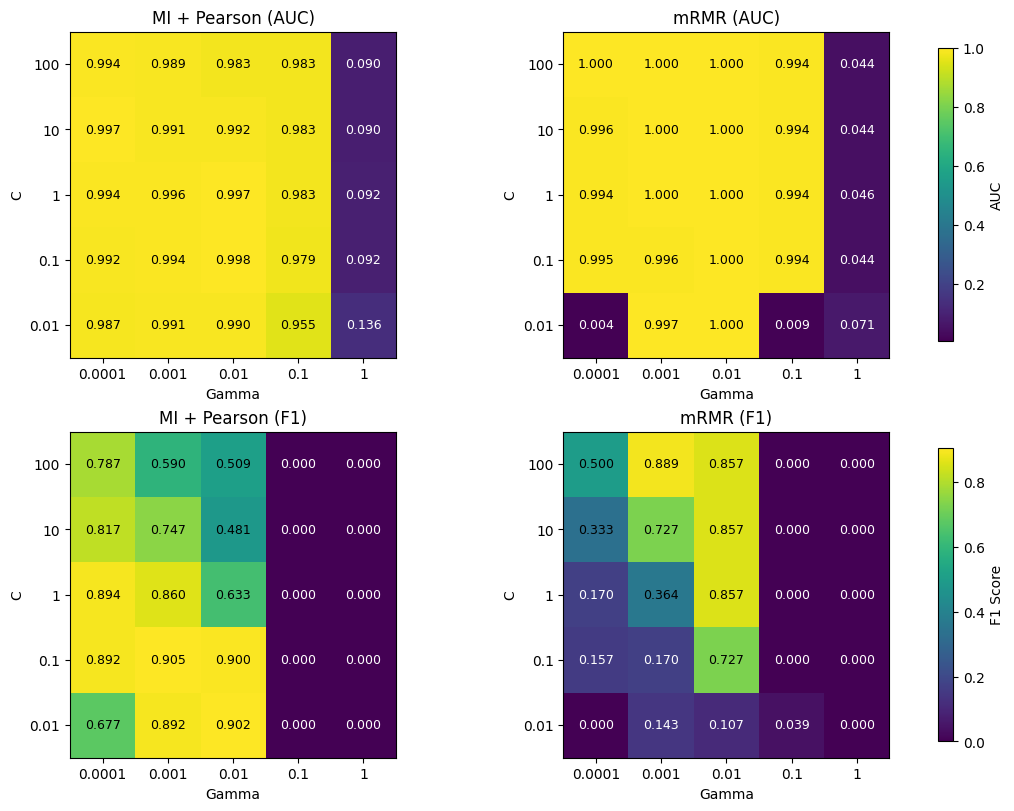

In [129]:


# -------------------------------------------------
# Same color scales
# -------------------------------------------------

auc_vmin = min(auc_mi.min(), auc_mrmr.min())
auc_vmax = max(auc_mi.max(), auc_mrmr.max())

f1_vmin = min(f1_mi.min(), f1_mrmr.min())
f1_vmax = max(f1_mi.max(), f1_mrmr.max())


# -------------------------------------------------
# Figure
# -------------------------------------------------

fig, ax = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True
)

im_auc = plot_heatmap(
    ax[0, 0],
    auc_mi,
    "MI + Pearson (AUC)",
    auc_vmin,
    auc_vmax
)

plot_heatmap(
    ax[0, 1],
    auc_mrmr,
    "mRMR (AUC)",
    auc_vmin,
    auc_vmax
)

im_f1 = plot_heatmap(
    ax[1, 0],
    f1_mi,
    "MI + Pearson (F1)",
    f1_vmin,
    f1_vmax
)

plot_heatmap(
    ax[1, 1],
    f1_mrmr,
    "mRMR (F1)",
    f1_vmin,
    f1_vmax
)

# -------------------------------------------------
# Colorbars
# -------------------------------------------------

fig.colorbar(
    im_auc,
    ax=[ax[0, 0], ax[0, 1]],
    location="right",
    shrink=0.9,
    label="AUC"
)

fig.colorbar(
    im_f1,
    ax=[ax[1, 0], ax[1, 1]],
    location="right",
    shrink=0.9,
    label="F1 Score"
)

plt.show()

# AQUI

In [ ]:
C_GRID = [ 0.01,0.1,1,10,100]
GAMMA_GRID = [0.0001, 0.001,0.01,0.1,1]

auc_mrmr,f1_mrmr  = evaluate_grid(
    X_train,
    y_train,
    X_test,
    y_test,
    selected_idx_1,
    C_GRID,
    GAMMA_GRID
)

In [187]:
import glob
file_list = sorted(glob.glob("../Features/Seizure/chb11_*.mat"))

for test_file in file_list:
    # Load test record
    with h5py.File(test_file, 'r') as f:
        X_test = f['all_feats'][:]
        y_test = f['all_labels'][:].squeeze()
    
    # Build training set from all other records
    X_train_list, y_train_list = [], []
    for train_file in file_list:
        if train_file == test_file:
            continue
        with h5py.File(train_file, 'r') as f:
            X_train_list.append(f['all_feats'][:])
            y_train_list.append(f['all_labels'][:].squeeze())
    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_train_list)
    
    # ---- Feature selection ONLY on training set ----
    selected_idx, _ = select_features_mi_pearson(X_train, y_train, k=20, prefilter=100)
    # ... (rest: scale, train SVM, predict, store metrics)

In [ ]:
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

In [190]:
import pandas as pd
from mrmr import mrmr_classif

# ---- Inside the training fold ----
X_train_df = pd.DataFrame(X_train)

# 
selected_idx_2 = mrmr_rank(
    X=X_train_df,
    y=pd.Series(y_train),
    k=20
)
X_train_sel = X_train[:, selected_idx_2]
X_test_sel = X_test[:, selected_idx_2]

In [194]:


gamma_scale = 1.0 / (X_train_sel.shape[1] * X_train_sel.var())
gamma_scale2 = 2 * gamma_scale
gamma_scale05 = 0.5 * gamma_scale

GAMMA_GRID = [gamma_scale05, gamma_scale2, gamma_scale]

In [198]:
C_GRID = [ 0.01,0.1,1,10,100]
GAMMA_GRID = ['scale',0.0001, 0.001,0.01,0.1,1]

auc_mi,f1_mi  = evaluate_grid(
    X_train,
    y_train,
    X_test,
    y_test,
    selected_idx_2,
    C_GRID,
    GAMMA_GRID
)

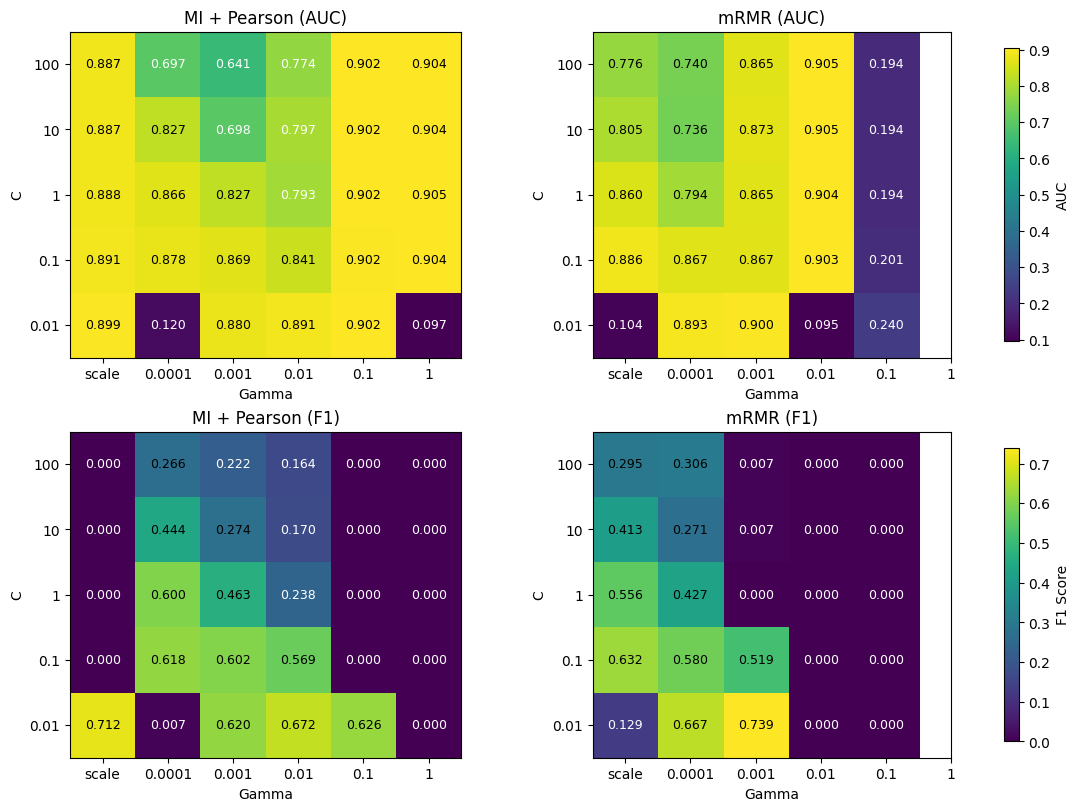

In [199]:


# -------------------------------------------------
# Same color scales
# -------------------------------------------------

auc_vmin = min(auc_mi.min(), auc_mrmr.min())
auc_vmax = max(auc_mi.max(), auc_mrmr.max())

f1_vmin = min(f1_mi.min(), f1_mrmr.min())
f1_vmax = max(f1_mi.max(), f1_mrmr.max())


# -------------------------------------------------
# Figure
# -------------------------------------------------

fig, ax = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True
)

im_auc = plot_heatmap(
    ax[0, 0],
    auc_mi,
    "MI + Pearson (AUC)",
    auc_vmin,
    auc_vmax
)

plot_heatmap(
    ax[0, 1],
    auc_mrmr,
    "mRMR (AUC)",
    auc_vmin,
    auc_vmax
)

im_f1 = plot_heatmap(
    ax[1, 0],
    f1_mi,
    "MI + Pearson (F1)",
    f1_vmin,
    f1_vmax
)

plot_heatmap(
    ax[1, 1],
    f1_mrmr,
    "mRMR (F1)",
    f1_vmin,
    f1_vmax
)

# -------------------------------------------------
# Colorbars
# -------------------------------------------------

fig.colorbar(
    im_auc,
    ax=[ax[0, 0], ax[0, 1]],
    location="right",
    shrink=0.9,
    label="AUC"
)

fig.colorbar(
    im_f1,
    ax=[ax[1, 0], ax[1, 1]],
    location="right",
    shrink=0.9,
    label="F1 Score"
)

plt.show()

In [93]:
set(selected_idx_1)-set(selected_idx_2)

{1023, 1024}

In [94]:
set(selected_idx_2)-set(selected_idx_1)

{139, 1244}

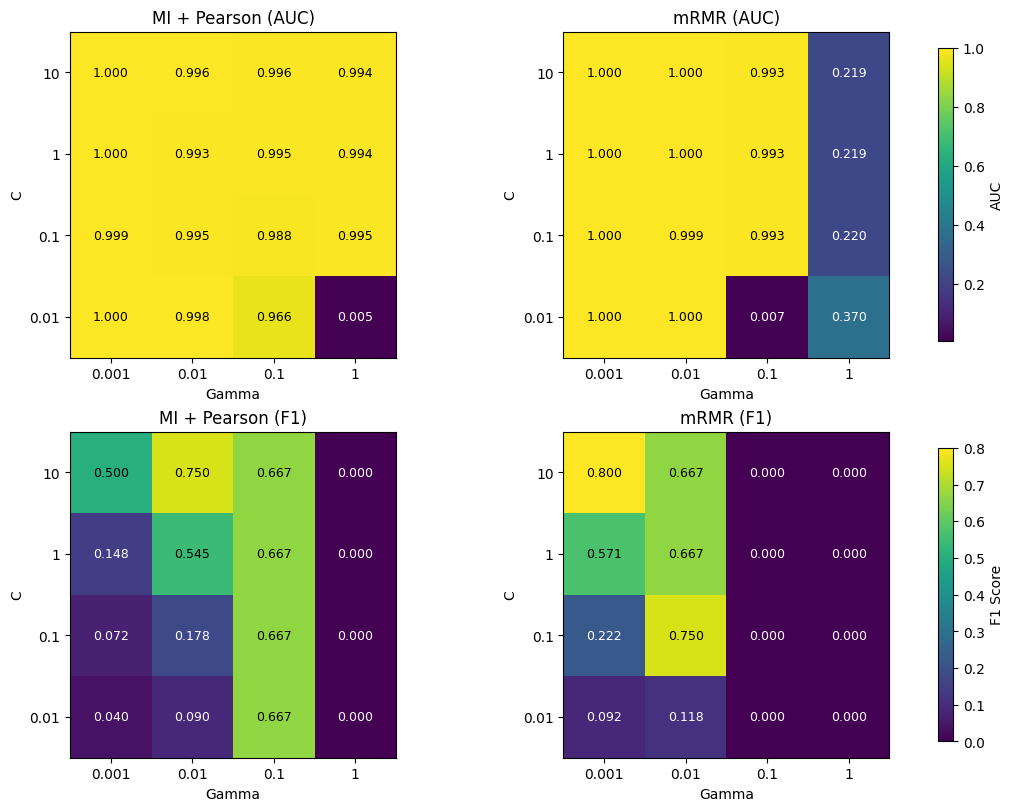

In [72]:


# -------------------------------------------------
# Same color scales
# -------------------------------------------------

auc_vmin = min(auc_mi.min(), auc_mrmr.min())
auc_vmax = max(auc_mi.max(), auc_mrmr.max())

f1_vmin = min(f1_mi.min(), f1_mrmr.min())
f1_vmax = max(f1_mi.max(), f1_mrmr.max())


# -------------------------------------------------
# Figure
# -------------------------------------------------

fig, ax = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True
)

im_auc = plot_heatmap(
    ax[0, 0],
    auc_mi,
    "MI + Pearson (AUC)",
    auc_vmin,
    auc_vmax
)

plot_heatmap(
    ax[0, 1],
    auc_mrmr,
    "mRMR (AUC)",
    auc_vmin,
    auc_vmax
)

im_f1 = plot_heatmap(
    ax[1, 0],
    f1_mi,
    "MI + Pearson (F1)",
    f1_vmin,
    f1_vmax
)

plot_heatmap(
    ax[1, 1],
    f1_mrmr,
    "mRMR (F1)",
    f1_vmin,
    f1_vmax
)

# -------------------------------------------------
# Colorbars
# -------------------------------------------------

fig.colorbar(
    im_auc,
    ax=[ax[0, 0], ax[0, 1]],
    location="right",
    shrink=0.9,
    label="AUC"
)

fig.colorbar(
    im_f1,
    ax=[ax[1, 0], ax[1, 1]],
    location="right",
    shrink=0.9,
    label="F1 Score"
)

plt.show()

In [ ]:
X_train_df = pd.DataFrame(X_train)

mrmr_idx = mrmr_classif(
    X=X_train_df,
    y=pd.Series(y_train),
    K=K
)

mrmr_idx = np.array(mrmr_idx)

In [12]:
from sklearn.feature_selection import f_classif

def select_features_anova(X_train, y_train, k=153):
    """
    Select top k features by ANOVA F-score.
    Returns list of indices.
    """
    f_scores, p_values = f_classif(X_train, y_train)
    # Handle possible NaN if a feature is constant
    f_scores = np.nan_to_num(f_scores)
    top_idx = np.argsort(f_scores)[-k:]
    return top_idx

In [13]:
def average_absolute_correlation(X, selected_indices):
    """Mean absolute Pearson r among all pairs of selected features."""
    if len(selected_indices) < 2:
        return 0.0
    corr = np.corrcoef(X[:, selected_indices], rowvar=False)
    corr = np.abs(corr)
    # Upper triangle without diagonal
    triu = np.triu_indices(len(selected_indices), k=1)
    return np.mean(corr[triu])

def jaccard_similarity(set1, set2):
    """Jaccard index between two sets of feature indices."""
    if len(set1) == 0 or len(set2) == 0:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)

def stability_across_folds(list_of_selected_sets):
    """
    Average pairwise Jaccard similarity across all pairs of folds.
    list_of_selected_sets: list of set of feature indices (one per fold).
    """
    n = len(list_of_selected_sets)
    if n < 2:
        return 1.0
    jaccards = []
    for i in range(n):
        for j in range(i+1, n):
            jaccards.append(jaccard_similarity(list_of_selected_sets[i],
                                               list_of_selected_sets[j]))
    return np.mean(jaccards)

In [6]:
pip install mrmr-selection

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ritaw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.feature_selection import mutual_info_classif

# Fixed number of features to select
K = 30

# ---------- MI-only feature selector ----------
def select_features_mi(X, y, k):
    mi = mutual_info_classif(X, y, random_state=42)
    idx = np.argsort(mi)[::-1][:k]
    return idx

# Storage for ANOVA
anova_auc = []
anova_f1 = []
anova_redundancy = []
anova_selected_sets = []

# Storage for MI only
mi_auc = []
mi_f1 = []
mi_redundancy = []
mi_selected_sets = []

# Storage for MI+Pearson
mrmr_auc = []
mrmr_f1 = []
mrmr_redundancy = []
mrmr_selected_sets = []

for test_file in file_list:

    # ---------- Build train/test split ----------
    with h5py.File(test_file, 'r') as f:
        X_test = f['all_feats'][:]
        y_test = f['all_labels'][:].squeeze()

    X_train_list, y_train_list = [], []

    for train_file in file_list:
        if train_file == test_file:
            continue

        with h5py.File(train_file, 'r') as f:
            X_train_list.append(f['all_feats'][:])
            y_train_list.append(f['all_labels'][:].squeeze())

    X_train = np.vstack(X_train_list)
    y_train = np.concatenate(y_train_list)

    # ============================================================
    # 1. ANOVA
    # ============================================================

    anova_idx = select_features_anova(X_train, y_train, k=K)
    anova_selected_sets.append(set(anova_idx))

    anova_red = average_absolute_correlation(X_train, anova_idx)
    anova_redundancy.append(anova_red)

    scaler_a = StandardScaler()

    X_train_sel_a = scaler_a.fit_transform(X_train[:, anova_idx])
    X_test_sel_a = scaler_a.transform(X_test[:, anova_idx])

    clf_a = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )

    clf_a.fit(X_train_sel_a, y_train)

    y_prob_a = clf_a.predict_proba(X_test_sel_a)[:, 1]
    y_pred_a = clf_a.predict(X_test_sel_a)

    anova_auc.append(roc_auc_score(y_test, y_prob_a))
    anova_f1.append(f1_score(y_test, y_pred_a))

    # ============================================================
    # 2. MI only
    # ============================================================

    mi_idx = select_features_mi(X_train, y_train, k=K)
    mi_selected_sets.append(set(mi_idx))

    mi_red = average_absolute_correlation(X_train, mi_idx)
    mi_redundancy.append(mi_red)

    scaler_mi = StandardScaler()

    X_train_sel_mi = scaler_mi.fit_transform(X_train[:, mi_idx])
    X_test_sel_mi = scaler_mi.transform(X_test[:, mi_idx])

    clf_mi = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )

    clf_mi.fit(X_train_sel_mi, y_train)

    y_prob_mi = clf_mi.predict_proba(X_test_sel_mi)[:, 1]
    y_pred_mi = clf_mi.predict(X_test_sel_mi)

    mi_auc.append(roc_auc_score(y_test, y_prob_mi))
    mi_f1.append(f1_score(y_test, y_pred_mi))

    # ============================================================
    # 3. MI + Pearson
    # ============================================================

    mrmr_idx, _ = select_features_mi_pearson(
        X_train,
        y_train,
        k=K,
        prefilter=100
    )

    mrmr_selected_sets.append(set(mrmr_idx))

    mrmr_red = average_absolute_correlation(X_train, mrmr_idx)
    mrmr_redundancy.append(mrmr_red)

    scaler_m = StandardScaler()

    X_train_sel_m = scaler_m.fit_transform(X_train[:, mrmr_idx])
    X_test_sel_m = scaler_m.transform(X_test[:, mrmr_idx])

    clf_m = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )

    clf_m.fit(X_train_sel_m, y_train)

    y_prob_m = clf_m.predict_proba(X_test_sel_m)[:, 1]
    y_pred_m = clf_m.predict(X_test_sel_m)

    mrmr_auc.append(roc_auc_score(y_test, y_prob_m))
    mrmr_f1.append(f1_score(y_test, y_pred_m))

# ============================================================
# Summary
# ============================================================

anova_stability = stability_across_folds(anova_selected_sets)
mi_stability = stability_across_folds(mi_selected_sets)
mrmr_stability = stability_across_folds(mrmr_selected_sets)

print("=== ANOVA (top K) ===")
print(f"AUC: {np.mean(anova_auc):.3f} ± {np.std(anova_auc):.3f}")
print(f"F1:  {np.mean(anova_f1):.3f} ± {np.std(anova_f1):.3f}")
print(f"Avg redundancy: {np.mean(anova_redundancy):.3f}")
print(f"Stability (Jaccard): {anova_stability:.3f}")

print("\n=== MI only (top K) ===")
print(f"AUC: {np.mean(mi_auc):.3f} ± {np.std(mi_auc):.3f}")
print(f"F1:  {np.mean(mi_f1):.3f} ± {np.std(mi_f1):.3f}")
print(f"Avg redundancy: {np.mean(mi_redundancy):.3f}")
print(f"Stability (Jaccard): {mi_stability:.3f}")

print("\n=== MI + Pearson (top K) ===")
print(f"AUC: {np.mean(mrmr_auc):.3f} ± {np.std(mrmr_auc):.3f}")
print(f"F1:  {np.mean(mrmr_f1):.3f} ± {np.std(mrmr_f1):.3f}")
print(f"Avg redundancy: {np.mean(mrmr_redundancy):.3f}")
print(f"Stability (Jaccard): {mrmr_stability:.3f}")

=== ANOVA (top K) ===
AUC: 0.665 ± 0.229
F1:  0.107 ± 0.119
Avg redundancy: 0.161
Stability (Jaccard): 0.157

=== MI only (top K) ===
AUC: 0.741 ± 0.097
F1:  0.096 ± 0.086
Avg redundancy: 0.137
Stability (Jaccard): 0.107

=== MI + Pearson (top K) ===
AUC: 0.715 ± 0.072
F1:  0.067 ± 0.080
Avg redundancy: 0.184
Stability (Jaccard): 0.121


In [ ]:
import numpy as np
import h5py
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.feature_selection import mutual_info_classif

# -----------------------------
# MI-only feature selector
# -----------------------------
def select_features_mi(X, y, k):
    mi = mutual_info_classif(X, y, random_state=42)
    return np.argsort(mi)[::-1][:k]

# List of k values to test
k_list = [5, 10, 50, 100]

# Results dictionaries
results_anova = {'k': [], 'auc': [], 'f1': [], 'redundancy': [], 'stability': []}
results_mi    = {'k': [], 'auc': [], 'f1': [], 'redundancy': [], 'stability': []}
results_mrmr  = {'k': [], 'auc': [], 'f1': [], 'redundancy': [], 'stability': []}

for K in k_list:

    print(f"Testing k = {K} ...")

    # Fold storage
    anova_auc, anova_f1, anova_red, anova_sets = [], [], [], []
    mi_auc, mi_f1, mi_red, mi_sets = [], [], [], []
    mrmr_auc, mrmr_f1, mrmr_red, mrmr_sets = [], [], [], []

    for test_file in file_list:

        # -----------------------------
        # Build train/test split
        # -----------------------------
        with h5py.File(test_file, 'r') as f:
            X_test = f['all_feats'][:]
            y_test = f['all_labels'][:].squeeze()

        X_train_list = []
        y_train_list = []

        for train_file in file_list:
            if train_file == test_file:
                continue

            with h5py.File(train_file, 'r') as f:
                X_train_list.append(f['all_feats'][:])
                y_train_list.append(f['all_labels'][:].squeeze())

        X_train = np.vstack(X_train_list)
        y_train = np.concatenate(y_train_list)

        # ==========================================================
        # ANOVA
        # ==========================================================
        anova_idx = select_features_anova(X_train, y_train, k=K)
        anova_sets.append(set(anova_idx))
        anova_red.append(average_absolute_correlation(X_train, anova_idx))

        scaler_a = StandardScaler()
        X_train_sel_a = scaler_a.fit_transform(X_train[:, anova_idx])
        X_test_sel_a = scaler_a.transform(X_test[:, anova_idx])

        clf_a = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42
        )

        clf_a.fit(X_train_sel_a, y_train)

        y_prob_a = clf_a.predict_proba(X_test_sel_a)[:, 1]
        y_pred_a = clf_a.predict(X_test_sel_a)

        anova_auc.append(roc_auc_score(y_test, y_prob_a))
        anova_f1.append(f1_score(y_test, y_pred_a))

        # ==========================================================
        # MI only
        # ==========================================================
        mi_idx = select_features_mi(X_train, y_train, k=K)
        mi_sets.append(set(mi_idx))
        mi_red.append(average_absolute_correlation(X_train, mi_idx))

        scaler_mi = StandardScaler()
        X_train_sel_mi = scaler_mi.fit_transform(X_train[:, mi_idx])
        X_test_sel_mi = scaler_mi.transform(X_test[:, mi_idx])

        clf_mi = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42
        )

        clf_mi.fit(X_train_sel_mi, y_train)

        y_prob_mi = clf_mi.predict_proba(X_test_sel_mi)[:, 1]
        y_pred_mi = clf_mi.predict(X_test_sel_mi)

        mi_auc.append(roc_auc_score(y_test, y_prob_mi))
        mi_f1.append(f1_score(y_test, y_pred_mi))

        # ==========================================================
        # MI + Pearson
        # ==========================================================
        mrmr_idx, _ = select_features_mi_pearson(
            X_train,
            y_train,
            k=K,
            prefilter=min(300, X_train.shape[1])
        )

        mrmr_sets.append(set(mrmr_idx))
        mrmr_red.append(average_absolute_correlation(X_train, mrmr_idx))

        scaler_m = StandardScaler()
        X_train_sel_m = scaler_m.fit_transform(X_train[:, mrmr_idx])
        X_test_sel_m = scaler_m.transform(X_test[:, mrmr_idx])

        clf_m = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42
        )

        clf_m.fit(X_train_sel_m, y_train)

        y_prob_m = clf_m.predict_proba(X_test_sel_m)[:, 1]
        y_pred_m = clf_m.predict(X_test_sel_m)

        mrmr_auc.append(roc_auc_score(y_test, y_prob_m))
        mrmr_f1.append(f1_score(y_test, y_pred_m))

    # ==========================================================
    # Aggregate results
    # ==========================================================

    anova_stab = stability_across_folds(anova_sets)
    mi_stab = stability_across_folds(mi_sets)
    mrmr_stab = stability_across_folds(mrmr_sets)

    results_anova['k'].append(K)
    results_anova['auc'].append(np.mean(anova_auc))
    results_anova['f1'].append(np.mean(anova_f1))
    results_anova['redundancy'].append(np.mean(anova_red))
    results_anova['stability'].append(anova_stab)

    results_mi['k'].append(K)
    results_mi['auc'].append(np.mean(mi_auc))
    results_mi['f1'].append(np.mean(mi_f1))
    results_mi['redundancy'].append(np.mean(mi_red))
    results_mi['stability'].append(mi_stab)

    results_mrmr['k'].append(K)
    results_mrmr['auc'].append(np.mean(mrmr_auc))
    results_mrmr['f1'].append(np.mean(mrmr_f1))
    results_mrmr['redundancy'].append(np.mean(mrmr_red))
    results_mrmr['stability'].append(mrmr_stab)

# ==========================================================
# Print results
# ==========================================================

print("\n=== ANOVA ===")
print("k\tAUC\tF1\tRedund\tStability")
for i in range(len(k_list)):
    print(
        f"{results_anova['k'][i]}\t"
        f"{results_anova['auc'][i]:.3f}\t"
        f"{results_anova['f1'][i]:.3f}\t"
        f"{results_anova['redundancy'][i]:.3f}\t"
        f"{results_anova['stability'][i]:.3f}"
    )

print("\n=== MI only ===")
print("k\tAUC\tF1\tRedund\tStability")
for i in range(len(k_list)):
    print(
        f"{results_mi['k'][i]}\t"
        f"{results_mi['auc'][i]:.3f}\t"
        f"{results_mi['f1'][i]:.3f}\t"
        f"{results_mi['redundancy'][i]:.3f}\t"
        f"{results_mi['stability'][i]:.3f}"
    )

print("\n=== MI + Pearson ===")
print("k\tAUC\tF1\tRedund\tStability")
for i in range(len(k_list)):
    print(
        f"{results_mrmr['k'][i]}\t"
        f"{results_mrmr['auc'][i]:.3f}\t"
        f"{results_mrmr['f1'][i]:.3f}\t"
        f"{results_mrmr['redundancy'][i]:.3f}\t"
        f"{results_mrmr['stability'][i]:.3f}"
    )

Testing k = 5 ...
Testing k = 10 ...
Testing k = 50 ...
Testing k = 100 ...


In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(results_anova['k'], results_anova['ap'], marker='o', label='ANOVA')
plt.plot(results_mrmr['k'], results_mrmr['ap'], marker='s', label='MI + Pearson')
plt.xlabel('Number of selected features (k)')
plt.ylabel('Average Precision')
plt.title('Average Precision vs Number of Selected Features')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'ap'

<Figure size 600x400 with 0 Axes>

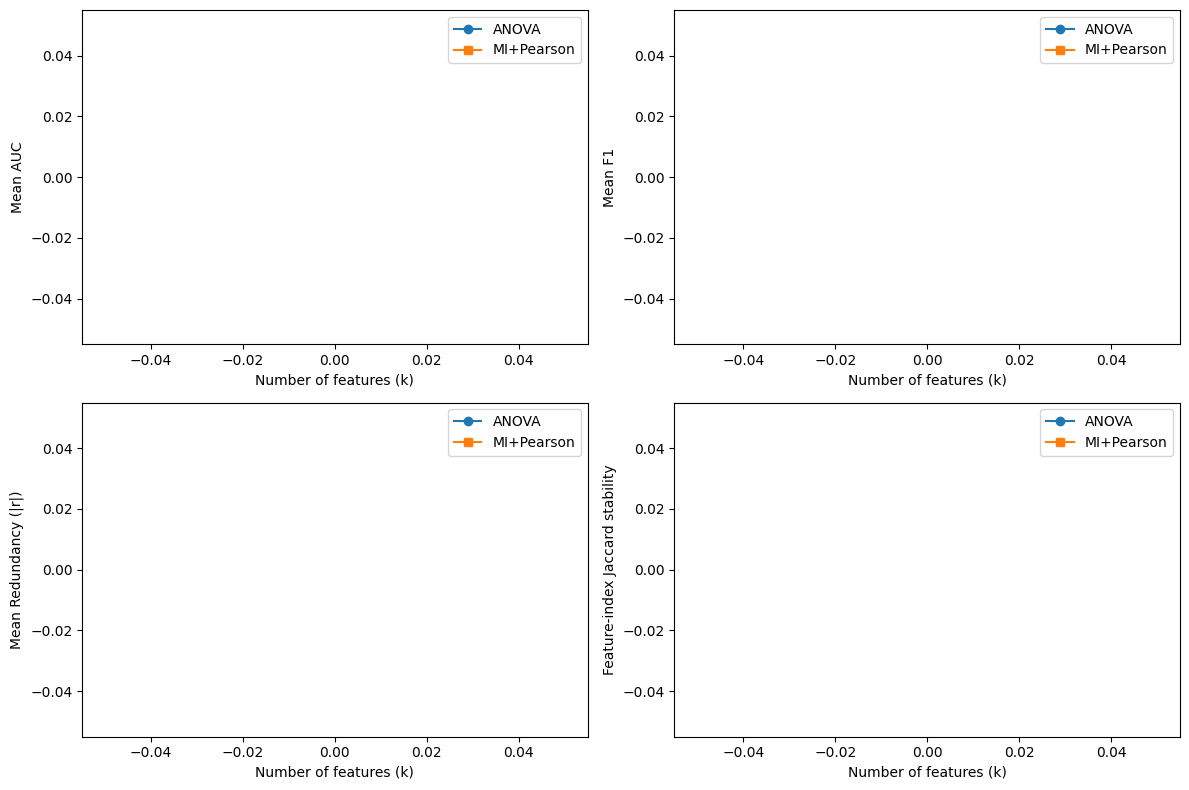

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(results_anova['k'], results_anova['auc'], 'o-', label='ANOVA')
plt.plot(results_mrmr['k'], results_mrmr['auc'], 's-', label='MI+Pearson')
plt.xlabel('Number of features (k)')
plt.ylabel('Mean AUC')
plt.legend()

plt.subplot(2,2,2)
plt.plot(results_anova['k'], results_anova['f1'], 'o-', label='ANOVA')
plt.plot(results_mrmr['k'], results_mrmr['f1'], 's-', label='MI+Pearson')
plt.xlabel('Number of features (k)')
plt.ylabel('Mean F1')
plt.legend()

plt.subplot(2,2,3)
plt.plot(results_anova['k'], results_anova['redundancy'], 'o-', label='ANOVA')
plt.plot(results_mrmr['k'], results_mrmr['redundancy'], 's-', label='MI+Pearson')
plt.xlabel('Number of features (k)')
plt.ylabel('Mean Redundancy (|r|)')
plt.legend()

plt.subplot(2,2,4)
plt.plot(results_anova['k'], results_anova['stability'], 'o-', label='ANOVA')
plt.plot(results_mrmr['k'], results_mrmr['stability'], 's-', label='MI+Pearson')
plt.xlabel('Number of features (k)')
plt.ylabel('Feature-index Jaccard stability')
plt.legend()

plt.tight_layout()
plt.show()

# 1. Load Features

In [5]:
# List all feature files
feature_dir = Path("../Features/Seizure")

files = sorted(feature_dir.glob("chb01_*_seizure.mat"))

print(len(files))
for f in files:
    print(f.name)

7
chb01_03_seizure.mat
chb01_04_seizure.mat
chb01_15_seizure.mat
chb01_16_seizure.mat
chb01_18_seizure.mat
chb01_21_seizure.mat
chb01_26_seizure.mat


In [6]:
# Load records into a dictionary

records = {}

for file in files:

    with h5py.File(file, "r") as f:

        X = f["all_feats"][:]
        y = f["all_labels"][:].squeeze()

    # If features are stored as (1530, n_windows)
    if X.shape[0] == 1530:
        X = X.T

    record_name = file.stem.replace("_features", "")

    records[record_name] = (X, y)

    print(record_name, X.shape, y.shape)

chb01_03_seizure (1437, 1530) (1437,)
chb01_04_seizure (1437, 1530) (1437,)
chb01_15_seizure (1437, 1530) (1437,)
chb01_16_seizure (1437, 1530) (1437,)
chb01_18_seizure (1437, 1530) (1437,)
chb01_21_seizure (1437, 1530) (1437,)
chb01_26_seizure (927, 1530) (927,)


In [7]:
# Put inside list
X_all = []
y_all = []

for name, (X, y) in records.items():
    X_all.append(X)
    y_all.append(y)

X_all = np.vstack(X_all)
y_all = np.hstack(y_all)

print(X_all.shape, y_all.shape)

(9549, 1530) (9549,)


## 1.1 Separate in Train/Test

In [6]:
# from sklearn.feature_selection import f_classif
# import numpy as np

# results = {}

# for test_record in records.keys():

#     print("\nTesting:", test_record)

#     # -----------------------
#     # Split LOSO
#     # -----------------------
#     X_train = []
#     y_train = []

#     X_test, y_test = records[test_record]

#     for name, (X, y) in records.items():

#         if name != test_record:
#             X_train.append(X)
#             y_train.append(y)

#     X_train = np.vstack(X_train)
#     y_train = np.hstack(y_train)


#     # -----------------------
#     # Feature selection ONLY on train
#     # -----------------------
#     F, p = f_classif(X_train, y_train)

#     idx = np.argsort(F)[::-1]

#     K = 100   # choose later
#     selected = idx[:K]


#     # Apply same features to test
#     X_train_sel = X_train[:, selected]
#     X_test_sel  = X_test[:, selected]


#     print("Train:", X_train_sel.shape)
#     print("Test :", X_test_sel.shape)

In [7]:
records.keys()

dict_keys(['chb01_03_seizure', 'chb01_04_seizure', 'chb01_15_seizure', 'chb01_16_seizure', 'chb01_18_seizure', 'chb01_21_seizure', 'chb01_26_seizure'])

In [9]:
# Separate 
results = {}

test_record = 'chb01_03_seizure'
# -----------------------
# Split LOSO
# -----------------------
X_train = []
y_train = []

X_test, y_test = records[test_record]

for name, (X, y) in records.items():

    if name != test_record:
        X_train.append(X)
        y_train.append(y)

X_train = np.vstack(X_train)
y_train = np.hstack(y_train)


In [ ]:
import numpy as np
import pandas as pd

# ==================================
# Correlation filter (TRAIN ONLY)
# ==================================

# Feature-feature correlation
corr_matrix = pd.DataFrame(X_train).corr().abs()

print("Correlation matrix:", corr_matrix.shape)
# should print (1530, 1530)


# Keep only upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


# Threshold
threshold = 0.95


# Find features to remove
to_drop = [
    col for col in upper.columns
    if any(upper[col] > threshold)
]


print("Highly correlated features:", len(to_drop))


# ==================================
# Apply same removal to train and test
# ==================================

keep_features = [
    i for i in range(X_train.shape[1])
    if i not in to_drop
]


X_train_corr = X_train[:, keep_features]
X_test_corr  = X_test[:, keep_features]


print("Before:", X_train.shape, X_test.shape)
print("After :", X_train_corr.shape, X_test_corr.shape)

In [10]:
import numpy as np

from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


# ============================
# Choose test record (LOSO)
# ============================

test_record = "chb01_03_seizure"

X_test, y_test = records[test_record]

X_train = []
y_train = []

for name, (X, y) in records.items():

    if name != test_record:
        X_train.append(X)
        y_train.append(y)


X_train = np.vstack(X_train)
y_train = np.hstack(y_train)


print("Train:", X_train.shape)
print("Test :", X_test.shape)


# ============================
# Feature selection (TRAIN ONLY)
# ============================

F, p = f_classif(X_train, y_train)

idx = np.argsort(F)[::-1]


K = 50  # test different values later

selected_features = idx[:K]


X_train_sel = X_train[:, selected_features]
X_test_sel  = X_test[:, selected_features]


print("Selected features:", X_train_sel.shape)


# ============================
# Scaling (TRAIN ONLY)
# ============================

scaler = StandardScaler()

X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)


# ============================
# Train SVM
# ============================

clf = SVC(
    kernel="rbf",
    probability=True,
    class_weight='balanced',
    C=0.1,
    gamma="scale",
    random_state=42
)

clf.fit(X_train_sel, y_train)


# ============================
# Evaluation
# ============================

y_pred = clf.predict(X_test_sel)
y_prob = clf.predict_proba(X_test_sel)[:, 1]


# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test, 
    y_pred,
    zero_division=0
)

sensitivity = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

specificity = tn / (tn + fp)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


auc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)


print(f"Accuracy     : {accuracy:.3f}")
print(f"Precision    : {precision:.3f}")
print(f"Sensitivity  : {sensitivity:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"F1-score     : {f1:.3f}")
print(f"ROC-AUC      : {auc:.3f}")
print(f"AUPRC        : {auprc:.3f}")

Train: (8112, 1530)
Test : (1437, 1530)
Selected features: (8112, 50)
Accuracy     : 0.981
Precision    : 0.357
Sensitivity  : 0.938
Specificity  : 0.981
F1-score     : 0.517
ROC-AUC      : 0.992
AUPRC        : 0.541
